In [1]:
import pandas as pd

df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1000, 9)

Column Data Types:
Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [3]:
print("Mean:")
print(df.mean(numeric_only=True))

print("\nMedian:")
print(df.median(numeric_only=True))

print("\nMode:")
print(df.mode(numeric_only=True).iloc[0])

print("\nStandard Deviation:")
print(df.std(numeric_only=True))

Mean:
Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

Median:
Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

Mode:
Transaction ID     1.0
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64

Standard Deviation:
Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


In [4]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total Amount'].sum()

print(monthly_sales)


Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64


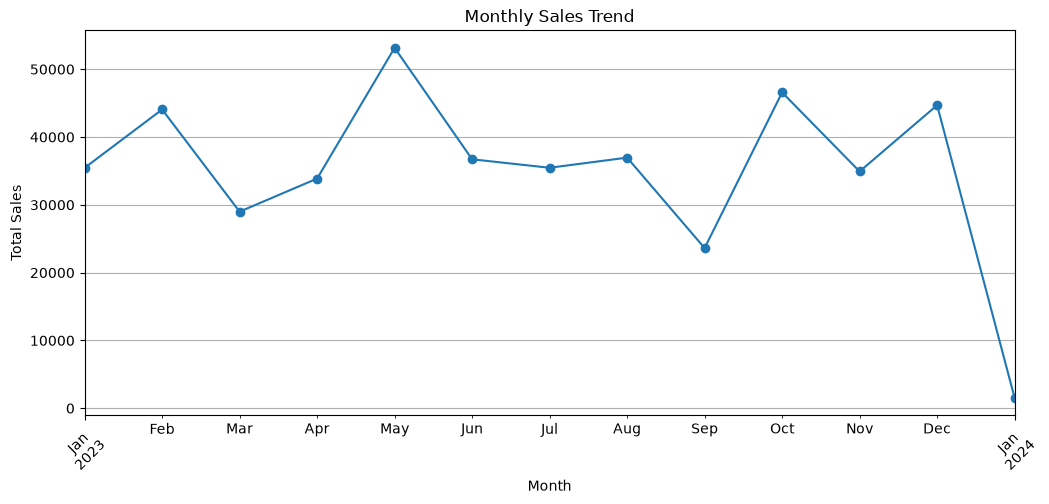

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



In [9]:
import matplotlib.pyplot as plt

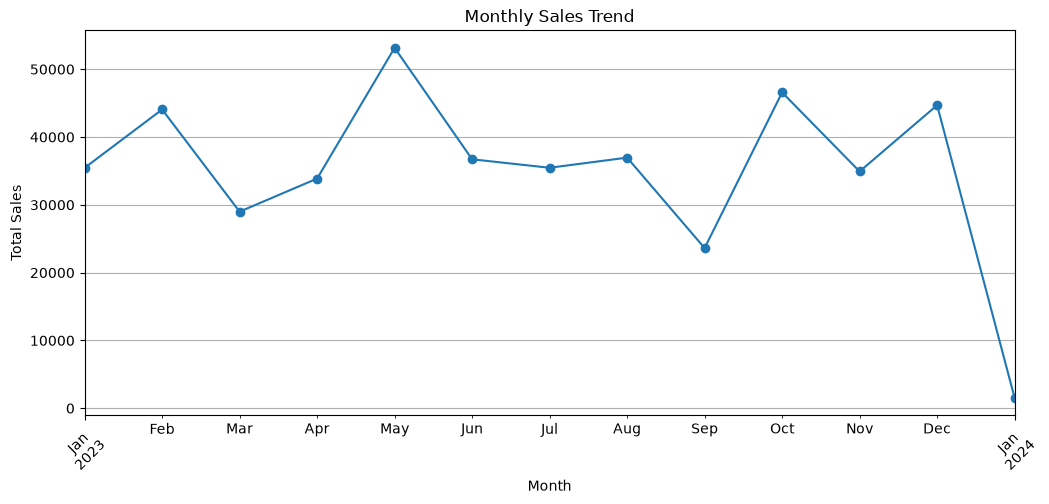

In [10]:
plt.figure(figsize=(12, 5))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Observation

Monthly sales fluctuate considerably throughout the period. December 2023 recorded high sales of 44,690, while January 2024 dropped sharply to 1,530. This suggests that sales can vary significantly between months and that seasonal or period-specific factors may influence purchasing activity.

In [13]:
df['Quarter'] = df['Date'].dt.to_period('Q')

quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

print(quarterly_sales)

Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64


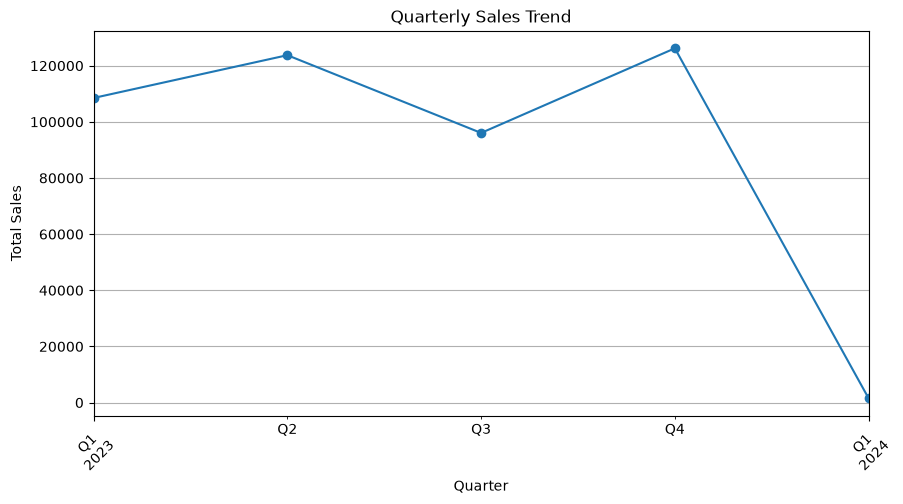

In [14]:
plt.figure(figsize=(10, 5))

quarterly_sales.plot(kind='line', marker='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [15]:
print(quarterly_sales)

Quarter
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64


### Observation

Quarterly sales show noticeable variation across the available period. Sales increased from ₹108,500 in Q1 2023 to ₹123,735 in Q2 2023, then declined to ₹96,045 in Q3 2023. Sales reached the highest level of ₹126,190 in Q4 2023. Q1 2024 recorded only ₹1,530, indicating a sharp decline compared with the previous quarter.

In [20]:
# Create age groups
bins = [17, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Count customers in each age group
age_group_counts = df['Age Group'].value_counts().sort_index()

print(age_group_counts)


Age Group
18-25    169
26-35    205
36-45    202
46-55    229
56-65    195
Name: count, dtype: int64


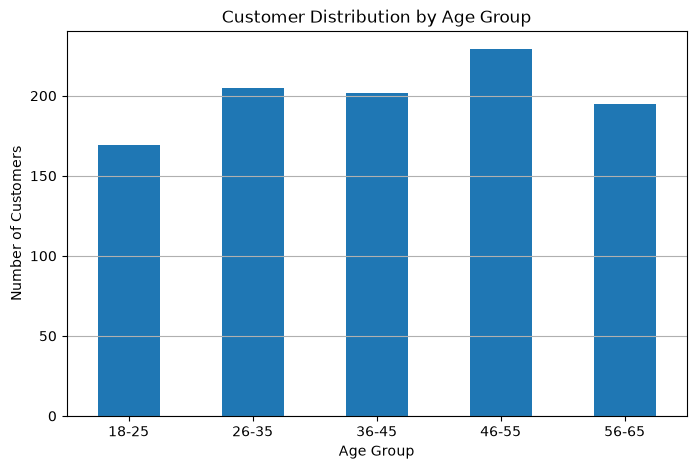

In [21]:
plt.figure(figsize=(8, 5))

age_group_counts.plot(kind='bar')

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

### Observation

The 46-55 age group has the highest number of customers with 229 records, followed by the 26-35 age group with 205 and the 36-45 age group with 202. The 18-25 age group has the lowest representation with 169 customers. Overall, customers are distributed across all age groups, with the 46-55 group showing the highest participation.

In [24]:
gender_counts = df ['Gender'].value_counts()

print(gender_counts)

Gender
Female    510
Male      490
Name: count, dtype: int64


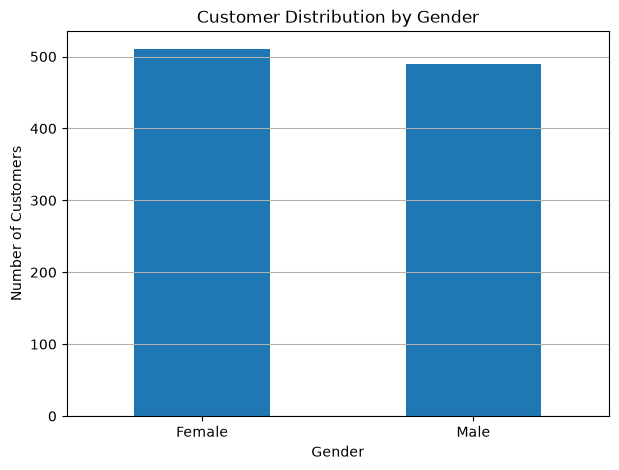

In [25]:
plt.figure(figsize=(7, 5))

gender_counts.plot(kind='bar')

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


### Observation

The dataset contains 510 female customers and 490 male customers. The distribution is relatively balanced, with female customers representing a slightly larger share of the dataset.

In [27]:
category_revenue = (
    df.groupby('Product Category')['Total Amount']
      .sum()
      .sort_values(ascending=False)
)

print(category_revenue)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


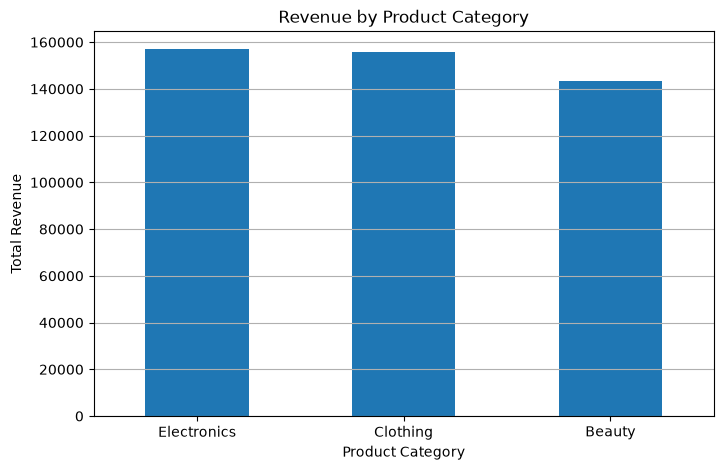

In [28]:
plt.figure(figsize=(8, 5))

category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


### Observation

Electronics generated the highest revenue of 156,905, followed closely by Clothing with 155,580. Beauty generated the lowest revenue at 143,515. The revenue difference between the three categories is relatively small, indicating a fairly balanced contribution from each product category.

In [29]:
corr = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr()

print(corr.round(2))

                 Age  Quantity  Price per Unit  Total Amount
Age             1.00     -0.02           -0.04         -0.06
Quantity       -0.02      1.00            0.02          0.37
Price per Unit -0.04      0.02            1.00          0.85
Total Amount   -0.06      0.37            0.85          1.00


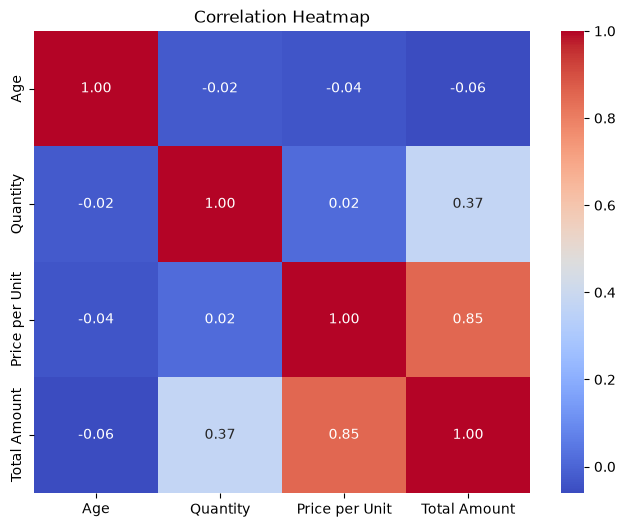

In [30]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

### Observation

The correlation heatmap shows the strength of relationships between Age, Quantity, Price per Unit, and Total Amount. The variables do not all have the same level of relationship, indicating that some factors are more closely associated with transaction value than others. Correlation shows association between variables and does not necessarily indicate causation.

In [31]:
avg_sales_age = df.groupby('Age Group', observed=False)['Total Amount'].mean()

print(avg_sales_age.round(2))


Age Group
18-25    500.30
26-35    480.39
36-45    454.80
46-55    439.69
56-65    412.36
Name: Total Amount, dtype: float64


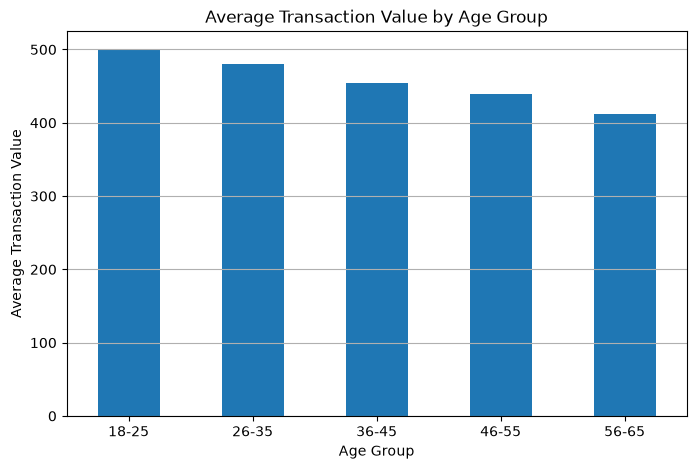

In [32]:
plt.figure(figsize=(8, 5))

avg_sales_age.plot(kind='bar')

plt.title('Average Transaction Value by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Transaction Value')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

### Observation

The 18-25 age group has the highest average transaction value at 500.30, followed by the 26-35 age group at 480.39. The average transaction value gradually decreases across the older age groups, with the 56-65 group having the lowest average of 412.36. This suggests that younger customers in this dataset tend to have higher average transaction values.

### Note on Product-Level Analysis

The dataset contains Product Category information but does not include individual product names or product IDs. Therefore, a Top 10 Products analysis cannot be performed accurately using this dataset without introducing unsupported assumptions. Instead, revenue by product category was analyzed.

# Conclusion

The exploratory data analysis provides several useful insights into the retail sales dataset. Sales varied considerably across months and quarters, with Q4 2023 recording the highest quarterly sales of 126,190. Electronics generated the highest category revenue at 156,905, followed closely by Clothing at 155,580, while Beauty generated 143,515.

The customer distribution was relatively balanced by gender, with 510 female and 490 male records. The 46-55 age group had the highest number of records with 229. However, the 18-25 age group recorded the highest average transaction value of 500.30, while the 56-65 group had the lowest average transaction value of 412.36.

Overall, the analysis shows differences in sales performance across time, product categories, and customer age groups. These findings can help support inventory planning, marketing decisions, and customer targeting.

## Actionable Business Recommendations

1. **Focus on high-performing categories:** Electronics generated the highest revenue, so the business can maintain sufficient inventory and consider targeted promotions for this category.

2. **Use age-based marketing:** The 18-25 age group had the highest average transaction value. The business can test targeted offers, digital promotions, and product recommendations for this segment.

3. **Plan according to sales trends:** Sales varied significantly across months and quarters. The business should monitor high-performing periods and plan inventory and promotional campaigns accordingly. The unusually low Q1 2024 sales should also be investigated to determine whether it reflects incomplete data or an actual decline.